In [2]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)
# https://drive.google.com/file/d/1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy/view?usp=sharing # tif delta clipped
!gdown --id 1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy

# https://drive.google.com/file/d/1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd/view?usp=sharing # polygons samples geojson
!gdown --id 1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1KquMbMWFK_2x02Hlvz8FCecuzcAwFCGy
To: /content/delta_1-7_bbox.tif
100% 5.27M/5.27M [00:00<00:00, 24.3MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd
To: /content/samples_delta.geojson
100% 18.5k/18.5k [00:00<00:00, 57.9MB/s]


In [3]:
# INSTALL LIBRARIES AND DEPENDENCIES
import geopandas as gpd
!pip install rasterio
import rasterio
from rasterio.mask import mask

from shapely.geometry import mapping

import matplotlib.pyplot as plt
import numpy as np

In [4]:
# OPEN L8 SCENE RASTER FILE
tif_path = f'/content/delta_1-7_bbox.tif' # dn image
tif = rasterio.open(tif_path)

## Histogram band 4-River sample

In [5]:
# READ AND VISUALIZE VECTOR FILE WITH SAMPLES AREAS

# read vector file with sampling areas
path_vector = '/content/samples_delta.geojson'
gdf_samples = gpd.read_file(path_vector).to_crs(tif.crs) # assign to the vector file the same crs as the tif

## visualize geodataframe
gdf_samples.head()

,id,cobertura,geometry
0,1,rio,"MULTIPOLYGON (((176645.609 -3672894.936, 17665..."
1,2,humedal,"MULTIPOLYGON (((184605.544 -3672560.284, 18462..."
2,3,urbano,"MULTIPOLYGON (((176048.016 -3677603.966, 17606..."
3,4,cultivo,"MULTIPOLYGON (((180637.528 -3678560.115, 18063..."


In [6]:
# FUNCTION TO EXTRACT BANDS VALUES FOR POSTERIOR PROCESSING AND VISUALIZATION (E.G. HISTOGRAM PLOT)

# extract bands digital numbers value for sampling areas
def df_firms_data(tif, band, gdf_samples, gdf_idx):

  geoms = gdf_samples.geometry.values

  # transform to GeJSON format (???)
  geoms = [mapping(geoms[gdf_idx])]

  out_image, out_transform = mask(tif, geoms, crop=True) # recorta la imagen segun ROI

  #print(out_image.shape)

  ma_data = np.ma.masked_equal(out_image, 0) # convierte los valores igual a 0 en Nan

  ma_data = ma_data[band-1].flatten()

  '''for i in range(len(bands_names)):
      df_bands_data[bands_names[i]] = ma_data[i].flatten()'''

  return ma_data#[band-1]

Text(0, 0.5, 'Count')

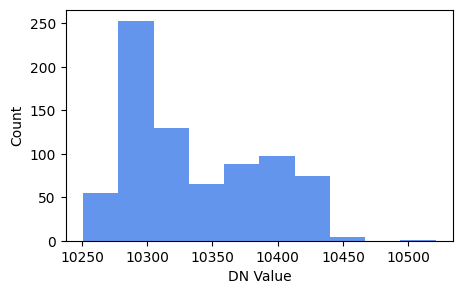

In [8]:
# Plot DN histogram river sample

# Get sampling area values from band 4
data_river = df_firms_data(tif, 4, gdf_samples, 0)

# Extract DN data from sample area
data_river = df_firms_data(tif, 4, gdf_samples, 0)

#Plot histogram
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(data_river, color='cornflowerblue' )
ax.set_xlabel('DN Value')
ax.set_ylabel('Count')

## DN to reflectance band 4

In [11]:
# OPEN AND EXTRACT BANDS DATA FROM IMAGE, AND STORE IN AN 3D NUMPY ARRAY
listBands_dn = []

with rasterio.open(tif_path) as src:

  profile = src.profile.copy()

  for b in range(1, tif.read().shape[0]+1):
      listBands_dn.append(src.read(b))

arrayBands_dn = np.array(listBands_dn)

In [12]:
# CONVERT DN DATA TO REFLECTANCE ACCORDING TO L8 SPECIFICATIONS
arrayBands_ref = (0.0000275*arrayBands_dn- 0.2)
arrayBands_ref = np.where(arrayBands_ref < 0, np.nan, arrayBands_ref)
arrayBands_ref = np.where(arrayBands_ref > 1, np.nan, arrayBands_ref)

In [13]:
# UPDATE THE EXTRACTED ORIGINAL RASTER PROFILE, AND THEN SAVE THE GENERATED TIF WITH N REFLECTANCE BANDS

# Define output file name
outfile = 'stack_1-7_ref.tif'

# Update profile
profile.update(
    tiled=True,
    blockxsize=256,  # Ensure blockxsize is a multiple of 16
    blockysize=256,  # Ensure blockysize is a multiple of 16
    count = arrayBands_ref.shape[0],   # Use the correct number of bands after concatenation
)

# Write the output with the NDVI band
with rasterio.open(outfile, "w", **profile) as dst:
    # write original bands
    for i in range(arrayBands_ref.shape[0]):
        dst.write(arrayBands_ref[i], i + 1)

Text(0, 0.5, 'Count')

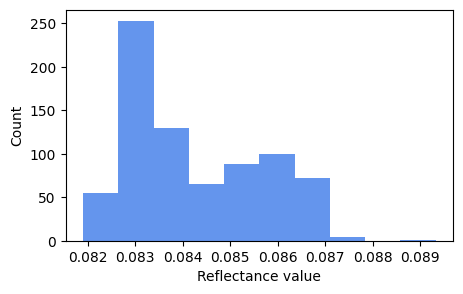

In [16]:
# OPEN THE REFLECTANCE DATA TIF FILE AND PLOT THE HISTOGRAM

# Open the raster file
tifRef_path = f'/content/stack_1-7_ref.tif'
tifRef = rasterio.open(tifRef_path)

# Extract reflectance data from sample area
data_river = df_firms_data(tifRef, 4, gdf_samples, 0)

## Plot histogram
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(data_river, color='cornflowerblue' )
ax.set_xlabel('Reflectance value')
ax.set_ylabel('Count')